In [6]:
import pandas as pd
import numpy as np
from datasets import load_from_disk, Dataset
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from collections import Counter
import pingouin as pg
from scipy.stats import ttest_rel

In [2]:
mpl.rcParams.update({
    'font.family'         : 'serif',       # Computer Modern — the default LaTeX font
    'font.size'           : 10,            # body text size (most journals use 10 pt)
    'axes.labelsize'      : 10,            # axis-label size matches body text
    'xtick.labelsize'     : 9,             # tick labels one point smaller
    'ytick.labelsize'     : 9,
    'legend.fontsize'     : 9,             # legend text one point smaller
    'axes.prop_cycle'     : mpl.cycler('color', [   # Okabe–Ito colorblind-safe palette
        '#0072B2', '#D55E00', '#009E73',
        '#E69F00', '#CC79A7', '#56B4E9',
    ]),
    'lines.linewidth'     : 1.5,           # slightly thicker for print clarity
    'axes.linewidth'      : 0.8,           # thinner axis frame
    'xtick.direction'     : 'in',          # inward ticks — journal standard
    'ytick.direction'     : 'in',
    'xtick.minor.visible' : True,          # show minor ticks
    'ytick.minor.visible' : True,
    'xtick.major.size'    : 4,             # longer than the 3.5 default
    'ytick.major.size'    : 4,
    'xtick.minor.size'    : 2,             # half of major — proportional
    'ytick.minor.size'    : 2,
    'xtick.major.width'   : 0.8,           # match axes.linewidth
    'ytick.major.width'   : 0.8,
    'xtick.minor.width'   : 0.6,           # thinner for visual hierarchy
    'ytick.minor.width'   : 0.6,
    'lines.markersize'    : 4,             # smaller markers for print scale
    'errorbar.capsize'    : 3,             # visible end-caps (default is 0)
    'axes.xmargin'        : 0.02,          # hug the data (default is 0.05)
    'axes.ymargin'        : 0.02,
    'legend.frameon'      : False,         # no legend box
    'savefig.bbox'        : 'tight',       # tight bounding box by default
    'savefig.dpi'         : 300,           # publication-quality resolution
    **(                                    # LaTeX if installed, else fallback
        {'text.usetex'        : True,              # real LaTeX for all text
         'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb}',
         'pgf.texsystem'     : 'pdflatex',         # consistent PGF export
         'pgf.rcfonts'       : False}               # let LaTeX control fonts
        if __import__('shutil').which('latex') else
        {'text.usetex'        : False,             # no TeX install found
         'mathtext.fontset'  : 'cm'}               # Computer Modern via mathtext
    ),
})

In [63]:
dev = pd.read_csv(r"DAIC-WOZ\dev\dev_split_Depression_AVEC2017.csv")

In [65]:
train = pd.read_csv(r"...\DAIC-WOZ\train\train_split_Depression_AVEC2017.csv")

In [66]:
test = pd.read_csv(r"...\DAIC-WOZ\test\full_test_split.csv")

In [62]:
full = pd.read_csv(r"...\full.csv")

In [17]:
full.columns

Index(['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender',
       'PHQ8_NoInterest', 'PHQ8_Depressed', 'PHQ8_Sleep', 'PHQ8_Tired',
       'PHQ8_Appetite', 'PHQ8_Failure', 'PHQ8_Concentrating', 'PHQ8_Moving'],
      dtype='str')

In [68]:
test.columns

Index(['Participant_ID', 'PHQ8_Binary', 'PHQ8_Score', 'Gender'], dtype='str')

In [68]:
test = test.rename(columns={'PHQ_Score': 'PHQ8_Score', 'PHQ_Binary': 'PHQ8_Binary'})

merged = pd.concat([full, test], ignore_index=True)

In [33]:
merged['Gender'].value_counts()

Gender
1    102
0     87
Name: count, dtype: int64

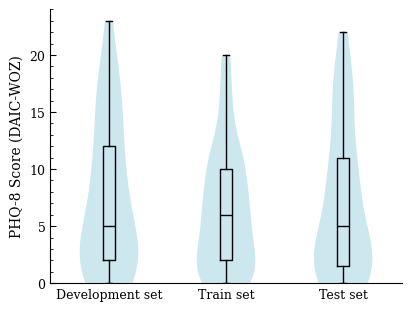

In [74]:
dev_scores = dev['PHQ8_Score'].values
train_scores = train['PHQ8_Score'].values
test_scores = test['PHQ8_Score'].values

data = [dev_scores, train_scores, test_scores]
labels = ['Development set', 'Train set', 'Test set']

fig, ax = plt.subplots(figsize=(120/25.4, 70/25.4), layout='constrained')

vp = ax.violinplot(data, positions=[1, 2, 3], vert=True, showextrema=False)
for pc in vp['bodies']:
    pc.set_facecolor('#B8DDE9')
    pc.set_alpha(0.7)

for i, d in enumerate(data, start=1):
    ax.boxplot(d, positions=[i], widths=0.1, vert=True,
               boxprops=dict(color='black'),
               whiskerprops=dict(color='black'),
               capprops=dict(color='black'),
               medianprops=dict(color='black'))

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(labels)
ax.tick_params(axis='x', length=0, which='both')
ax.set_ylim(0, 24)
ax.set_ylabel('PHQ-8 Score (DAIC-WOZ)')
ax.spines[['top', 'right']].set_visible(False)
fig.set_size_inches(4, 3) 
fig.savefig('woz_phq_distribution_splits.pdf')

In [75]:
print(len(dev_scores), len(train_scores), len(test_scores))

35 107 47


In [27]:
test.dtypes

Participant_ID    int64
PHQ_Binary        int64
PHQ_Score         int64
Gender            int64
dtype: object

In [3]:
groningen = pd.read_excel(r"...\secret\sheet.xlsx")

In [4]:
gro = groningen[['Participants', 'ID', 'Group', 'Invitation?', 'Q_1', 'Q_2', 'Q_3', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'PHQ9_total', 'Category']].copy()

In [48]:
actual = gro[gro['ID'].notna()]

In [50]:
actual['Q_2'].value_counts()

Q_2
Female              40
Male                14
Non-binary/Other     5
Name: count, dtype: int64

In [61]:
gro_phq = pd.read_pickle(r"...\phq.pkl")

In [90]:
gro_phq = gro_phq[['pre_ID', 'group_pre', 'phq8_pre', 'phq8_post']]

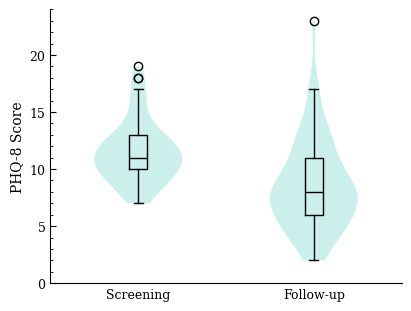

In [73]:
pre_scores = gro_phq['phq8_pre'].dropna().values
post_scores = gro_phq['phq8_post'].dropna().values

data = [pre_scores, post_scores]
labels = ['Screening', 'Follow-up']

fig, ax = plt.subplots(figsize=(85/25.4, 70/25.4), layout='constrained')

vp = ax.violinplot(data, positions=[1, 2], vert=True, showextrema=False)
for body in vp['bodies']:
    body.set_facecolor('#7DDBD0')
    body.set_alpha(0.4)

for i, d in enumerate(data, start=1):
    #jitter = np.random.uniform(-0.05, 0.05, size=len(d))
    #ax.scatter(i + jitter, d, alpha=0.4, s=8, color='#7DDBD0', zorder=3)
    ax.boxplot(d, positions=[i], widths=0.1, vert=True,
               boxprops=dict(color='black'),
               whiskerprops=dict(color='black'),
               capprops=dict(color='black'),
               medianprops=dict(color='black'))

ax.set_xticks([1, 2])
ax.set_xticklabels(labels)
ax.tick_params(axis='x', length=0, which='both')
ax.set_ylim(0, 24)
ax.set_ylabel('PHQ-8 Score')
ax.spines[['top', 'right']].set_visible(False)
fig.set_size_inches(4, 3) 
fig.savefig('phq_groningen_pre_post.pdf')

In [91]:
complete = gro_phq[['phq8_pre', 'phq8_post']].dropna()
t, p = ttest_rel(complete['phq8_pre'], complete['phq8_post'])
print(f"t = {t:.3f}, p = {p:.3f}, n = {len(complete)}")

t = 4.829, p = 0.000, n = 58


In [108]:
result = pg.ttest(complete['phq8_pre'], complete['phq8_post'], paired=True)
print(result)

              T  dof alternative     p_val        CI95   cohen_d     power  \
T_test  4.82917   57   two-sided  0.000011  [1.7, 4.1]  0.853048  0.999995   

            BF10  
T_test  1735.524  


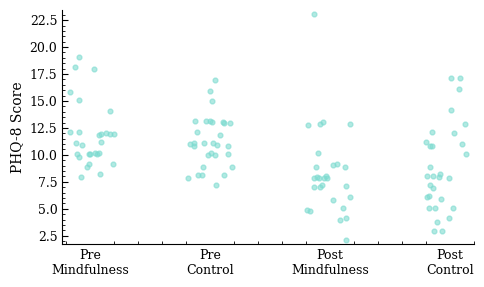

In [98]:
groups = [
    gro_phq[gro_phq['group_pre'] == 1]['phq8_pre'].dropna().values,
    gro_phq[gro_phq['group_pre'] == 0]['phq8_pre'].dropna().values,
    gro_phq[gro_phq['group_pre'] == 1]['phq8_post'].dropna().values,
    gro_phq[gro_phq['group_pre'] == 0]['phq8_post'].dropna().values,
]
labels = ['Pre\nMindfulness', 'Pre\nControl', 'Post\nMindfulness', 'Post\nControl']

fig, ax = plt.subplots(figsize=(120/25.4, 70/25.4), layout='constrained')

for i, d in enumerate(groups, start=1):
    x_jitter = np.random.uniform(-0.2, 0.2, size=len(d))
    y_jitter = np.random.uniform(-0.2, 0.2, size=len(d))
    ax.scatter(i + x_jitter, d + y_jitter, alpha=0.6, s=12, color='#7DDBD0', zorder=3)

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(labels)
ax.tick_params(axis='x', length=0)
ax.set_ylabel('PHQ-8 Score')
ax.spines[['top', 'right']].set_visible(False)
fig.savefig('phq_by_group_pre_post.pdf')

In [107]:
pre = gro_phq[['pre_ID', 'group_pre', 'phq8_pre']].dropna().copy()
pre.columns = ['subject', 'group', 'phq']
pre['time'] = 'Pre'

post = gro_phq[['pre_ID', 'group_pre', 'phq8_post']].dropna().copy()
post.columns = ['subject', 'group', 'phq']
post['time'] = 'Post'

long = pd.concat([pre, post], ignore_index=True)
long['group'] = long['group'].map({1: 'Mindfulness', 0: 'Control'})

result = pg.mixed_anova(data=long, dv='phq', within='time', between='group', subject='subject')
print(result)

        Source          SS  DF1  DF2          MS          F     p_unc  \
0        group    0.042036    1   56    0.042036   0.003271  0.954595   
1         time  243.310345    1   56  243.310345  23.210760  0.000011   
2  Interaction    7.661084    1   56    7.661084   0.730834  0.396256   

        np2  eps  
0  0.000058  NaN  
1  0.293025  1.0  
2  0.012882  NaN  


In [106]:
long

,subject,group,phq,time
0,0,Control,12,Pre
1,1,Control,12,Pre
2,2,Control,8,Pre
3,3,Control,10,Pre
4,4,Mindfulness,10,Pre
...,...,...,...,...
111,111,Control,11,Post
112,112,Mindfulness,5,Post
113,113,Control,7,Post
114,114,Control,6,Post


In [3]:
woz = pd.read_pickle(r"...\woz.pkl")

In [10]:
woz = load_from_disk(r"...\woz")

Loading dataset from disk:   0%|          | 0/24 [00:00<?, ?it/s]

In [11]:
woz = woz.remove_columns(['audio', 'input_values'])

In [23]:
woz.to_pickle("woz_without_audio.pkl")

In [18]:
woz = pd.read_pickle("woz_features")
woz = woz.drop(columns=["gender"])
woz.to_pickle("woz_eGeMAPS_features.pkl")

In [19]:
woz

,participant,segment_number,phq_score,split,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
0,492,0.0,0,dev,32.459476,0.127084,29.662060,32.069675,34.859688,5.197628,...,-0.011759,0.006834,0.007030,2.351176,1.404917,0.279643,0.257411,0.394138,0.429181,-49.025673
1,492,1.0,0,dev,29.640329,0.109005,28.285152,29.532978,32.000751,3.715599,...,-0.007221,0.002618,0.010657,2.851426,1.705971,0.236765,0.157157,0.328824,0.379626,-47.838284
2,492,2.0,0,dev,29.476030,0.081869,28.111883,29.196026,30.748175,2.636292,...,-0.009746,0.004036,0.011845,3.251626,2.308078,0.243043,0.143237,0.189268,0.199761,-46.271103
3,492,3.0,0,dev,30.120560,0.079050,28.492973,29.677343,31.673737,3.180763,...,-0.009725,0.007440,0.008675,2.351176,1.805416,0.220000,0.176855,0.313889,0.305798,-48.810707
4,492,4.0,0,dev,30.825378,0.106487,28.630680,30.447668,33.970924,5.340244,...,-0.010612,0.004589,0.010592,2.401201,1.805416,0.254444,0.136940,0.271081,0.317267,-46.845509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6006,491,21.0,8,train,29.740639,0.152050,25.089584,29.382435,34.286362,9.196777,...,-0.007399,0.012992,0.007838,2.151076,1.856498,0.205946,0.157179,0.321667,0.769204,-44.753227
6007,491,22.0,8,train,30.344494,0.122782,28.212555,30.069744,32.042049,3.829494,...,-0.008288,0.011588,0.007551,1.600800,1.304566,0.246923,0.174483,0.499231,0.708047,-44.791740
6008,491,23.0,8,train,30.519840,0.122934,26.718548,30.366028,33.987576,7.269028,...,-0.006959,0.011566,0.009317,2.201101,1.354062,0.258148,0.187459,0.443571,0.667972,-46.185310
6009,491,24.0,8,train,29.753126,0.130178,27.789640,29.717810,32.450012,4.660372,...,-0.002819,0.002350,0.027792,2.901451,2.157551,0.257907,0.186866,0.194146,0.195722,-40.089756


In [20]:
woz = pd.read_pickle("predictions.pkl")
woz = woz.drop(columns=["source_file", "gender"])
woz['prediction'] = woz['prediction'] * 24.0
woz
woz.to_pickle("woz_phqs.pkl")

In [ ]:
epe = pd.read_parquet("embeddings_per_epoch_final_model.parquet")

In [28]:
#epe = embeddings per epoch - save only epoch 0 from df with embeddings from epoch 0 and 1
epe = pd.read_parquet("embeddings_epoch_0_to_1.parquet")
ee0 = epe[epe['epoch'] == 0]
ee0.to_parquet("embeddings_epoch_0.parquet")

In [29]:
#epe = embeddings per epoch - save only epoch 20 from df with embeddings from epoch 1 to 20 (larger than 100MB)
epe = pd.read_parquet("embeddings_epoch_1_to_20.parquet")
ee20 = epe[epe['epoch'] == 20]
ee20.to_parquet("embeddings_epoch_20.parquet")

In [31]:
embeddings_epoch_0_and_20 = pd.concat([ee0, ee20], ignore_index=True)
embeddings_epoch_0_and_20.to_parquet("embeddings_epoch_0_and_20.parquet")
embeddings_epoch_0_and_20

,0,1,2,3,4,5,6,7,8,9,...,761,762,763,764,765,766,767,epoch,participant,labels
0,-0.117124,0.030386,0.141310,0.037132,0.153043,-0.196688,0.161134,-0.144997,-0.086940,-0.150796,...,0.021067,-0.366357,0.003402,-0.180400,0.266079,0.378878,-0.366035,0,481,0.291667
1,-0.144757,0.060951,0.237330,0.056462,0.130119,-0.312398,0.096692,-0.198697,-0.101838,-0.180656,...,0.041842,-0.445531,0.009561,-0.150405,0.228443,0.377793,-0.346304,0,481,0.291667
2,-0.071041,0.018597,0.113162,0.059740,0.188473,-0.168902,0.102792,-0.177824,-0.115774,-0.118513,...,-0.028645,-0.449664,-0.005567,-0.179551,0.280017,0.332765,-0.368200,0,481,0.291667
3,-0.100556,0.060595,0.187044,0.041390,0.229701,-0.233982,0.126529,-0.185728,-0.082636,-0.156990,...,0.010031,-0.445496,-0.010148,-0.185968,0.230344,0.352549,-0.326248,0,481,0.291667
4,-0.118969,0.042637,0.211373,0.012776,0.148007,-0.208083,0.108838,-0.175369,-0.143792,-0.100448,...,-0.012869,-0.482796,0.012716,-0.169513,0.265104,0.280917,-0.389017,0,481,0.291667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3333,0.034189,0.307398,-0.195306,0.325418,0.309829,-0.166594,0.112488,-0.198989,-0.110062,-0.194876,...,-0.114820,-0.131843,0.010566,-0.180814,0.162274,0.529404,-0.075519,20,480,0.041667
3334,0.059867,0.267020,-0.137457,0.249929,0.348753,-0.147940,0.086667,-0.287552,-0.127959,-0.225551,...,0.000760,-0.059247,-0.070071,-0.106870,0.166677,0.468300,-0.113225,20,480,0.041667
3335,0.040183,0.260262,-0.093431,0.241736,0.358261,-0.182046,0.177488,-0.210871,-0.081704,-0.181016,...,0.039281,-0.096697,-0.008158,-0.152027,0.210239,0.455434,-0.086574,20,480,0.041667
3336,-0.079027,0.223451,-0.144688,0.271348,0.427411,-0.291276,0.185604,-0.278877,0.009816,-0.123116,...,0.076265,-0.161299,0.021529,-0.121516,0.066862,0.477599,-0.164759,20,480,0.041667


In [10]:
import numpy as np
from collections import Counter

# get participant and segment_number columns as lists
participants = woz['participant']
segment_numbers = woz['segment_number']

# find max segment number per participant
from itertools import groupby

participant_max = {}
for p, s in zip(participants, segment_numbers):
    if p not in participant_max or s > participant_max[p]:
        participant_max[p] = s

# max + 1 = number of segments
segment_counts_per_participant = [v + 1 for v in participant_max.values()]

# value counts
woz_counts = Counter(segment_counts_per_participant)
woz_indices = sorted(woz_counts.keys())
woz_vals = [woz_counts[i] for i in woz_indices]

In [13]:
# convert from 0-indexed (min == 0) to 1-indexed:
segment_counts_per_participant = [v + 1 for v in participant_max.values()]

# total seconds (each segment = 20s)
total_seconds = sum(segment_counts_per_participant) * 20
total_minutes = total_seconds / 60
total_hours = total_minutes / 60

print(f"Total recording length: {total_seconds}s / {total_minutes:.1f}min / {total_hours:.2f}hrs")

Total recording length: 119820.0s / 1997.0min / 33.28hrs


In [14]:
seconds_per_participant = [s * 20 for s in segment_counts_per_participant]
seconds_per_participant

[620.0,
 360.0,
 520.0,
 580.0,
 980.0,
 1340.0,
 1060.0,
 780.0,
 460.0,
 440.0,
 520.0,
 1020.0,
 540.0,
 540.0,
 820.0,
 420.0,
 700.0,
 600.0,
 800.0,
 680.0,
 1100.0,
 380.0,
 1060.0,
 1080.0,
 1140.0,
 900.0,
 580.0,
 300.0,
 960.0,
 760.0,
 1280.0,
 720.0,
 360.0,
 360.0,
 820.0,
 260.0,
 560.0,
 540.0,
 600.0,
 320.0,
 380.0,
 1260.0,
 520.0,
 420.0,
 500.0,
 600.0,
 1660.0,
 860.0,
 260.0,
 820.0,
 460.0,
 1020.0,
 980.0,
 540.0,
 620.0,
 280.0,
 460.0,
 420.0,
 1300.0,
 1040.0,
 380.0,
 720.0,
 1160.0,
 500.0,
 840.0,
 480.0,
 600.0,
 800.0,
 1200.0,
 640.0,
 980.0,
 540.0,
 680.0,
 560.0,
 720.0,
 860.0,
 1240.0,
 700.0,
 840.0,
 640.0,
 800.0,
 720.0,
 440.0,
 1420.0,
 520.0,
 480.0,
 420.0,
 460.0,
 460.0,
 340.0,
 400.0,
 420.0,
 720.0,
 380.0,
 620.0,
 300.0,
 320.0,
 800.0,
 420.0,
 600.0,
 560.0,
 320.0,
 560.0,
 260.0,
 580.0,
 440.0,
 740.0,
 560.0,
 260.0,
 400.0,
 600.0,
 500.0,
 580.0,
 520.0,
 440.0,
 700.0,
 220.0,
 400.0,
 220.0,
 340.0,
 820.0,
 1420.0,
 1040.

In [17]:
seconds_per_participant

[620.0,
 360.0,
 520.0,
 580.0,
 980.0,
 1340.0,
 1060.0,
 780.0,
 460.0,
 440.0,
 520.0,
 1020.0,
 540.0,
 540.0,
 820.0,
 420.0,
 700.0,
 600.0,
 800.0,
 680.0,
 1100.0,
 380.0,
 1060.0,
 1080.0,
 1140.0,
 900.0,
 580.0,
 300.0,
 960.0,
 760.0,
 1280.0,
 720.0,
 360.0,
 360.0,
 820.0,
 260.0,
 560.0,
 540.0,
 600.0,
 320.0,
 380.0,
 1260.0,
 520.0,
 420.0,
 500.0,
 600.0,
 1660.0,
 860.0,
 260.0,
 820.0,
 460.0,
 1020.0,
 980.0,
 540.0,
 620.0,
 280.0,
 460.0,
 420.0,
 1300.0,
 1040.0,
 380.0,
 720.0,
 1160.0,
 500.0,
 840.0,
 480.0,
 600.0,
 800.0,
 1200.0,
 640.0,
 980.0,
 540.0,
 680.0,
 560.0,
 720.0,
 860.0,
 1240.0,
 700.0,
 840.0,
 640.0,
 800.0,
 720.0,
 440.0,
 1420.0,
 520.0,
 480.0,
 420.0,
 460.0,
 460.0,
 340.0,
 400.0,
 420.0,
 720.0,
 380.0,
 620.0,
 300.0,
 320.0,
 800.0,
 420.0,
 600.0,
 560.0,
 320.0,
 560.0,
 260.0,
 580.0,
 440.0,
 740.0,
 560.0,
 260.0,
 400.0,
 600.0,
 500.0,
 580.0,
 520.0,
 440.0,
 700.0,
 220.0,
 400.0,
 220.0,
 340.0,
 820.0,
 1420.0,
 1040.

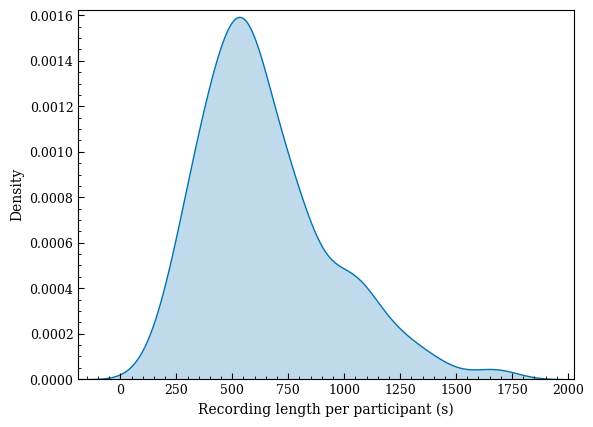

In [18]:
sns.kdeplot(seconds_per_participant, fill=True)
plt.xlabel('Recording length per participant (s)')
plt.ylabel('Density')
plt.show()

In [59]:
counts = Counter(woz['participant'])
segment_counts = list(counts.values())

In [140]:
woz_indices = all_indices

In [ ]:
fig, ax = plt.subplots(figsize=(85/25.4, 70/25.4), layout='constrained')
ax.boxplot(segment_counts, vert=True)
ax.set_ylabel('Segments per participant')
ax.spines[['top', 'right']].set_visible(False)
fig.show()
#fig.savefig('segments_per_participant.pdf')

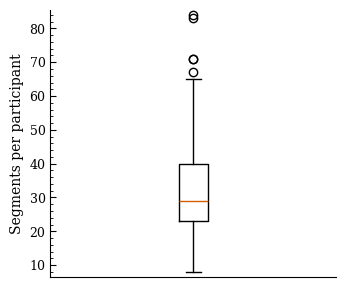

In [113]:
fig, ax = plt.subplots(figsize=(85/25.4, 70/25.4), layout='constrained')
#ax.violinplot(segment_counts, positions=[1])
ax.boxplot(segment_counts, positions=[1], widths=0.1)
ax.set_ylabel('Segments per participant')
ax.set_xticks([])
ax.spines[['top', 'right']].set_visible(False)
fig.savefig('woz_segments_per_participant.pdf')

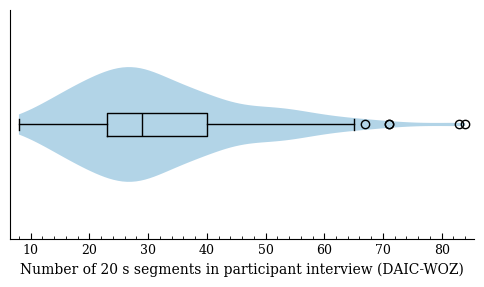

In [128]:
fig, ax = plt.subplots(figsize=(120/25.4, 70/25.4), layout='constrained')
ax.violinplot(segment_counts, positions=[1], vert=False, showextrema=False)
boxprops = dict(color='black')
whiskerprops = dict(color='black')
capprops = dict(color='black')
medianprops = dict(color='black')
ax.boxplot(segment_counts, positions=[1], widths=0.1, vert=False,
            boxprops=boxprops, whiskerprops=whiskerprops,
            capprops=capprops, medianprops=medianprops)
ax.set_xlabel('Number of 20 s segments in participant interview (DAIC-WOZ)')
ax.set_yticks([])
ax.spines[['top', 'right']].set_visible(False)
fig.savefig('woz_segments_per_participant.pdf')

In [10]:
del woz

In [19]:
home = pd.read_pickle(r"...\home_df")

In [21]:
home = home.drop(columns=['audio', 'input_values'])

In [24]:
home.to_pickle("home_without_audio.pkl")

In [29]:
daily_counts = home.groupby('day')['participant'].nunique()
daily_counts

day
1     50
2     54
3     51
4     52
5     50
6     52
7     53
8     56
9     54
10    53
11    51
12    50
13    49
14    48
Name: participant, dtype: int64

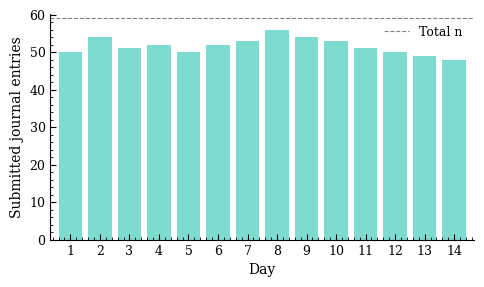

In [76]:
daily_counts = home.groupby('day')['participant'].nunique()

fig, ax = plt.subplots(figsize=(120/25.4, 70/25.4), layout='constrained')
ax.bar(daily_counts.index, daily_counts.values, color='#7DDBD0')
ax.set_xlabel('Day')
ax.set_ylabel('Submitted journal entries')
ax.set_xticks(range(1, 15))
ax.axhline(59, color='grey', linewidth=0.8, linestyle='--', label='Total n')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
fig.savefig('submitted_entries_per_day.pdf')

In [31]:
home_segments = home.groupby(['participant', 'day'])['segment_number'].max() + 1
seconds_per_participant_home = (home_segments * 20).tolist()
seconds_per_participant_home

[60,
 60,
 80,
 60,
 60,
 60,
 60,
 60,
 80,
 60,
 100,
 100,
 80,
 80,
 60,
 40,
 40,
 60,
 40,
 40,
 40,
 40,
 40,
 40,
 60,
 40,
 40,
 40,
 40,
 80,
 60,
 100,
 40,
 60,
 60,
 40,
 60,
 80,
 60,
 60,
 60,
 60,
 120,
 80,
 60,
 60,
 40,
 40,
 60,
 20,
 60,
 100,
 100,
 80,
 60,
 60,
 120,
 60,
 60,
 60,
 80,
 60,
 60,
 80,
 40,
 40,
 80,
 60,
 60,
 80,
 60,
 60,
 60,
 60,
 80,
 80,
 120,
 120,
 80,
 100,
 80,
 60,
 100,
 80,
 120,
 120,
 80,
 60,
 60,
 160,
 40,
 60,
 60,
 60,
 60,
 40,
 60,
 40,
 60,
 60,
 60,
 60,
 60,
 100,
 220,
 120,
 80,
 60,
 80,
 160,
 80,
 80,
 100,
 60,
 100,
 80,
 140,
 100,
 140,
 100,
 40,
 60,
 80,
 60,
 40,
 120,
 80,
 100,
 140,
 140,
 140,
 60,
 140,
 180,
 120,
 100,
 160,
 180,
 160,
 60,
 80,
 60,
 80,
 80,
 100,
 80,
 80,
 60,
 100,
 80,
 80,
 80,
 100,
 100,
 120,
 100,
 80,
 100,
 80,
 80,
 60,
 60,
 40,
 40,
 60,
 60,
 60,
 60,
 60,
 60,
 40,
 40,
 40,
 60,
 20,
 140,
 60,
 160,
 80,
 80,
 60,
 80,
 60,
 120,
 60,
 120,
 80,
 60,
 60,
 60,
 80

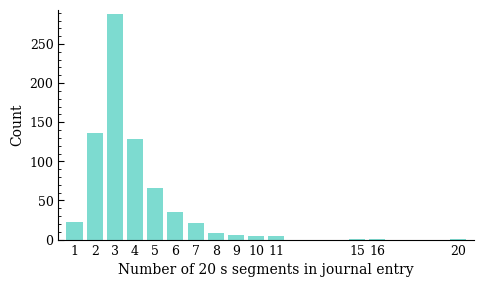

In [17]:
max_segments = home.groupby(['participant', 'day'])['segment_number'].max() + 1
home_counts = max_segments.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(120/25.4, 70/25.4), layout='constrained')
ax.bar(home_counts.index, home_counts.values, color='#7DDBD0')
ax.set_xlabel('Number of 20 s segments in journal entry')
ax.set_ylabel('Count')
ax.set_xticks(sorted(home_counts.index))
ax.tick_params(axis='x', length=0)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.spines[['top', 'right']].set_visible(False)
fig.savefig('home_segment_number_counts.pdf')

In [9]:
del home

In [25]:
mic = pd.read_pickle(r"...\mic_questions_merged.pkl")

In [27]:
mic = mic.drop(columns=['audio'])

In [28]:
mic.to_pickle("mic_qqs_merged_without_audio.pkl")

In [33]:
mic_segments = mic.groupby(['participant', 't'])['segment_number'].max() + 1
seconds_per_participant_mic = (mic_segments * 20).tolist()
seconds_per_participant_mic

[220,
 40,
 80,
 260,
 60,
 100,
 380,
 120,
 140,
 540,
 140,
 100,
 380,
 160,
 40,
 160,
 20,
 40,
 600,
 140,
 180,
 340,
 80,
 120,
 320,
 80,
 120,
 400,
 140,
 100,
 220,
 80,
 80,
 220,
 120,
 40,
 280,
 60,
 60,
 280,
 60,
 60,
 520,
 220,
 100,
 120,
 20,
 20,
 560,
 180,
 180,
 800,
 160,
 80,
 620,
 160,
 180,
 360,
 80,
 40,
 240,
 60,
 60,
 340,
 80,
 60,
 380,
 100,
 80,
 540,
 160,
 140,
 400,
 100,
 80,
 320,
 100,
 100,
 280,
 80,
 120,
 440,
 140,
 140,
 400,
 60,
 120,
 480,
 140,
 140,
 580,
 120,
 140,
 240,
 60,
 80,
 340,
 60,
 80,
 220,
 80,
 40,
 580,
 160,
 120,
 180,
 80,
 240,
 80,
 60,
 620,
 260,
 140,
 480,
 160,
 100,
 240,
 100,
 60,
 240,
 80,
 80,
 360,
 120,
 120,
 180,
 60,
 40,
 680,
 260,
 180,
 240,
 60,
 40,
 240,
 60,
 80,
 280,
 60,
 100,
 720,
 220,
 180,
 480,
 140,
 60,
 680,
 160,
 180,
 300,
 80,
 100,
 420,
 140,
 80,
 540,
 140,
 180,
 200,
 60,
 60,
 140,
 40,
 20,
 260,
 60,
 80,
 280,
 80,
 80]

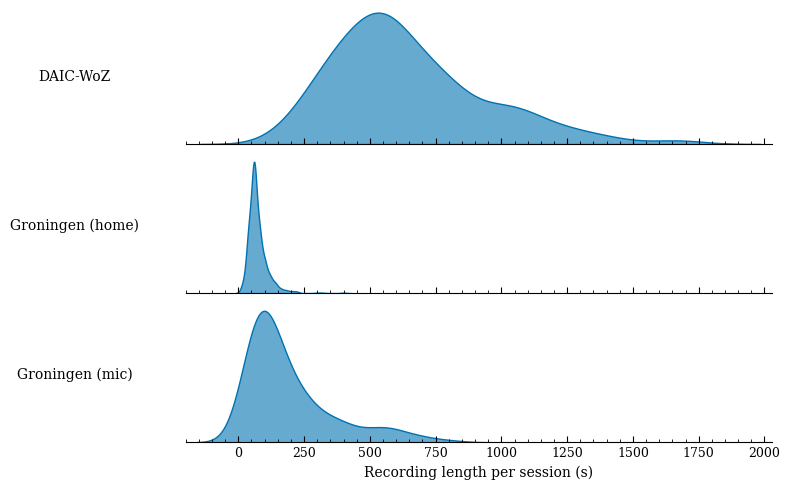

In [41]:
datasets = {
    'DAIC-WoZ': seconds_per_participant,
    'Groningen (home)': seconds_per_participant_home,
    'Groningen (mic)': seconds_per_participant_mic
}

fig, axes = plt.subplots(3, 1, figsize=(8, 5), sharex=True)

for ax, (label, data) in zip(axes, datasets.items()):
    sns.kdeplot(data, fill=True, ax=ax, alpha=0.6)
    ax.set_ylabel(label, rotation=0, labelpad=80, va='center')
    ax.set_yticks([])
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

axes[-1].set_xlabel('Recording length per session (s)')
plt.tight_layout()
plt.show()

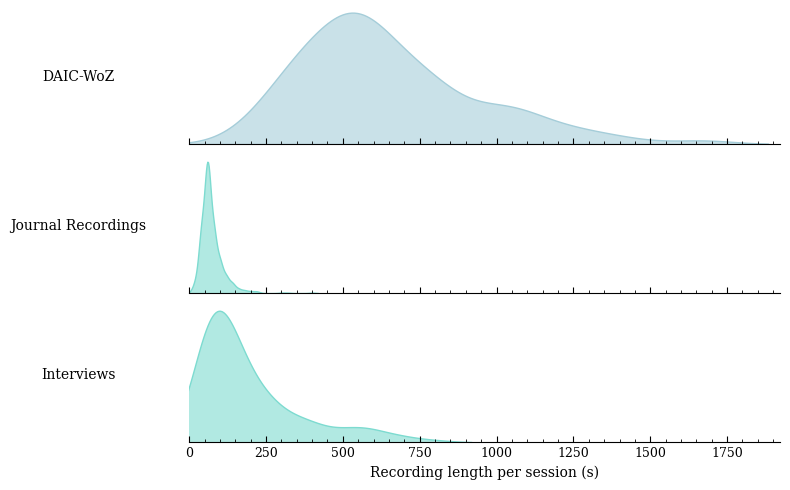

In [51]:
datasets = {
    'DAIC-WoZ': (seconds_per_participant, '#A5CDD9'),
    'Journal Recordings': (seconds_per_participant_home, '#7DDBD0'),
    'Interviews': (seconds_per_participant_mic, '#7DDBD0')
}

fig, axes = plt.subplots(3, 1, figsize=(8, 5), sharex=True)

for ax, (label, (data, color)) in zip(axes, datasets.items()):
    sns.kdeplot(data, fill=True, ax=ax, alpha=0.6, color=color, cut=2)
    ax.set_xlim(left=0)
    ax.set_ylabel(label, rotation=0, labelpad=80, va='center')
    ax.set_yticks([])
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

axes[-1].set_xlabel('Recording length per session (s)')
plt.tight_layout()
plt.savefig('segment_distributions_all.pdf', bbox_inches='tight')
plt.show()

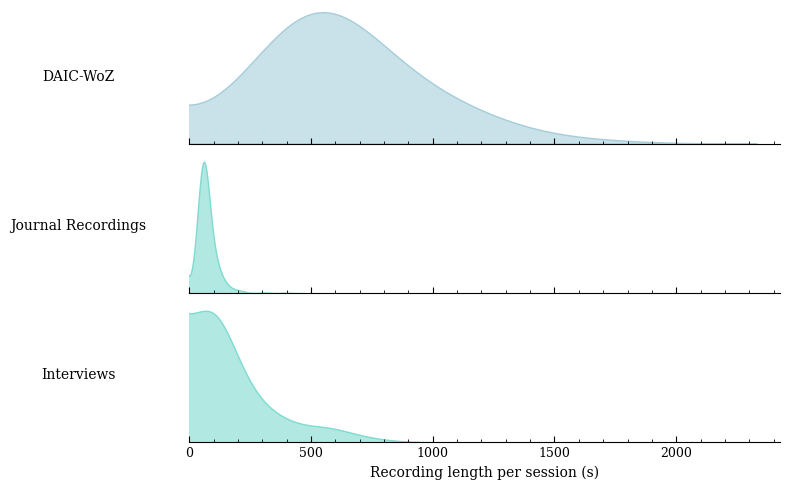

In [44]:
import numpy as np

def kde_with_boundary(ax, data, color, alpha=0.6):
    data = np.array(data)
    reflected = np.concatenate([data, -data])  # reflect around 0
    sns.kdeplot(reflected, fill=True, ax=ax, alpha=alpha, color=color)
    ax.set_xlim(left=0)  # only show positive half

datasets = {
    'DAIC-WoZ': (seconds_per_participant, '#A5CDD9'),
    'Journal Recordings': (seconds_per_participant_home, '#7DDBD0'),
    'Interviews': (seconds_per_participant_mic, '#7DDBD0')
}

fig, axes = plt.subplots(3, 1, figsize=(8, 5), sharex=True)

for ax, (label, (data, color)) in zip(axes, datasets.items()):
    kde_with_boundary(ax, data, color)
    ax.set_ylabel(label, rotation=0, labelpad=80, va='center')
    ax.set_yticks([])
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

axes[-1].set_xlabel('Recording length per session (s)')
plt.tight_layout()
plt.show()

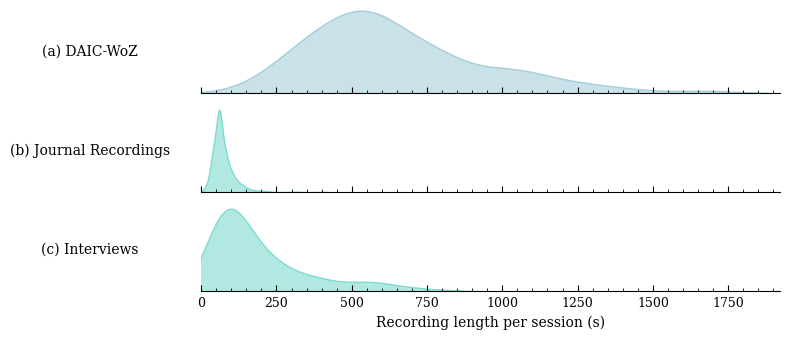

In [60]:
fig, axes = plt.subplots(3, 1, figsize=(8, 3.5), sharex=True)

for i, (ax, (label, (data, color))) in enumerate(zip(axes, datasets.items())):
    sns.kdeplot(data, fill=True, ax=ax, alpha=0.6, color=color, cut=2)
    ax.set_xlim(left=0)
    ax.set_ylabel(f'({chr(97+i)}) {label}', rotation=0, labelpad=80, va='center')
    ax.set_yticks([])
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

axes[-1].set_xlabel('Recording length per session (s)')
plt.tight_layout()
plt.savefig('segment_distributions.pdf', bbox_inches='tight')
plt.show()

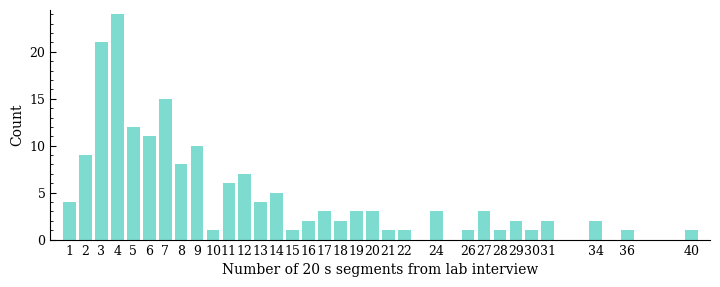

In [5]:
max_segments = mic.groupby(['participant', 't'])['segment_number'].max() + 1
mic_counts = max_segments.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(180/25.4, 70/25.4), layout='constrained')
ax.bar(mic_counts.index, mic_counts.values, color='#7DDBD0')
ax.set_xlabel('Number of 20 s segments from lab interview')
ax.set_ylabel('Count')
ax.set_xticks(sorted(mic_counts.index))
ax.tick_params(axis='x', length=0)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.spines[['top', 'right']].set_visible(False)
fig.savefig('mic_segment_number_counts.pdf')

In [126]:
del mic

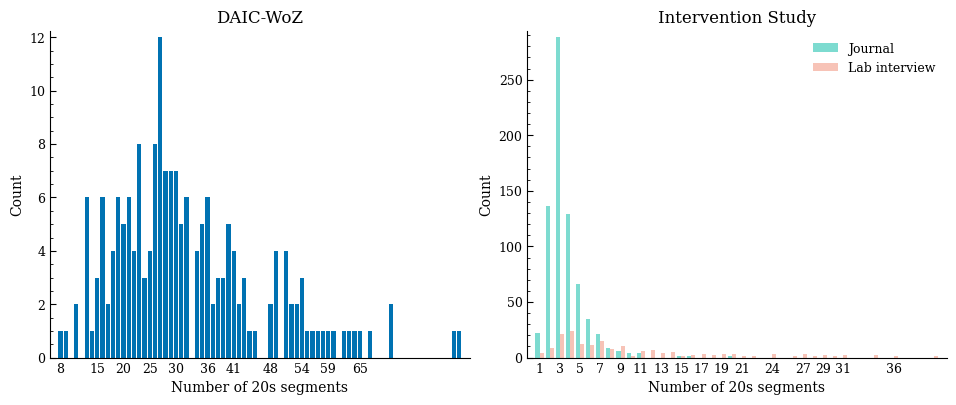

In [151]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(240/25.4, 100/25.4), layout='constrained')

# --- LEFT: DAIC-WoZ ---
ax1.bar(woz_indices, woz_vals)
ax1.set_xlabel('Number of 20s segments')
ax1.set_ylabel('Count')
ax1.set_title('DAIC-WoZ')
ax1.set_xticks(woz_indices[::5])
ax1.tick_params(axis='x', length=0)
ax1.xaxis.set_minor_locator(plt.NullLocator())
ax1.spines[['top', 'right']].set_visible(False)

# --- RIGHT: two overlapping vertical bars ---
butterfly_indices = sorted(set(home_counts.index) | set(mic_counts.index))
home_vals = [home_counts.get(i, 0) for i in butterfly_indices]
mic_vals = [mic_counts.get(i, 0) for i in butterfly_indices]

width = 0.4
x = np.array(butterfly_indices)
ax2.bar(x - width/2, home_vals, width=width, color='#7DDBD0', label='Journal')
ax2.bar(x + width/2, mic_vals, width=width, color='#F5B5A5', alpha=0.8, label='Lab interview')
ax2.set_xlabel('Number of 20s segments')
ax2.set_ylabel('Count')
ax2.set_title('Intervention Study')
ax2.set_xticks(x[::2])
ax2.tick_params(axis='x', length=0)
ax2.xaxis.set_minor_locator(plt.NullLocator())
ax2.legend()
ax2.spines[['top', 'right']].set_visible(False)

fig.savefig('combined_segments.pdf')

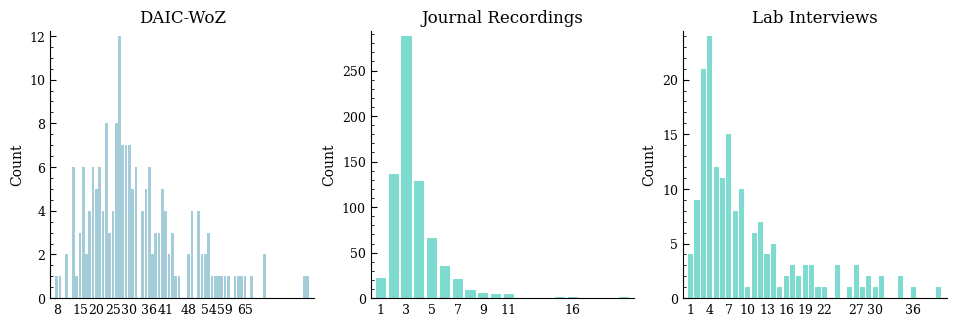

In [18]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(240/25.4, 80/25.4), layout='constrained')

# --- LEFT: DAIC-WoZ ---
ax1.bar(woz_indices, woz_vals, color='#A5CDD9')
#ax1.set_xlabel('Number of 20s segments')
ax1.set_ylabel('Count')
ax1.set_title('DAIC-WoZ')
ax1.set_xticks(woz_indices[::5])
ax1.tick_params(axis='x', length=0)
ax1.xaxis.set_minor_locator(plt.NullLocator())
ax1.spines[['top', 'right']].set_visible(False)

# --- MIDDLE: Journal ---
home_indices = sorted(home_counts.index)
home_vals = [home_counts[i] for i in home_indices]

ax2.bar(home_indices, home_vals, color='#7DDBD0')
#ax2.set_xlabel('Number of 20s segments')
ax2.set_ylabel('Count')
ax2.set_title('Journal Recordings')
ax2.set_xticks(home_indices[::2])
ax2.tick_params(axis='x', length=0)
ax2.xaxis.set_minor_locator(plt.NullLocator())
ax2.spines[['top', 'right']].set_visible(False)

# --- RIGHT: Lab interview ---
mic_indices = sorted(mic_counts.index)
mic_vals = [mic_counts[i] for i in mic_indices]

ax3.bar(mic_indices, mic_vals, color='#7DDBD0')
#ax3.set_xlabel('Number of 20s segments')
ax3.set_ylabel('Count')
ax3.set_title('Lab Interviews')
ax3.set_xticks(mic_indices[::2])
ax3.tick_params(axis='x', length=0)
ax3.xaxis.set_minor_locator(plt.NullLocator())
ax3.set_xticks(mic_indices[::3])
ax3.spines[['top', 'right']].set_visible(False)

fig.savefig('combined_segments.pdf')

In [19]:
mm = 1/25.4

# --- LEFT: DAIC-WoZ ---
fig, ax = plt.subplots(figsize=(80/25.4, 80/25.4), layout='constrained')
ax.bar(woz_indices, woz_vals, color='#A5CDD9')
ax.set_ylabel('Count')
ax.set_xticks(woz_indices[::5])
ax.tick_params(axis='x', length=0)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.spines[['top', 'right']].set_visible(False)
fig.savefig('segments_woz.pdf')
plt.close()

# --- MIDDLE: Journal ---
home_indices = sorted(home_counts.index)
home_vals = [home_counts[i] for i in home_indices]
fig, ax = plt.subplots(figsize=(80/25.4, 80/25.4), layout='constrained')
ax.bar(home_indices, home_vals, color='#7DDBD0')
ax.set_ylabel('Count')
ax.set_xticks(home_indices[::2])
ax.tick_params(axis='x', length=0)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.spines[['top', 'right']].set_visible(False)
fig.savefig('segments_home.pdf')
plt.close()

# --- RIGHT: Lab interview ---
mic_indices = sorted(mic_counts.index)
mic_vals = [mic_counts[i] for i in mic_indices]
fig, ax = plt.subplots(figsize=(80/25.4, 80/25.4), layout='constrained')
ax.bar(mic_indices, mic_vals, color='#7DDBD0')
ax.set_ylabel('Count')
ax.set_xticks(mic_indices[::3])
ax.tick_params(axis='x', length=0)
ax.xaxis.set_minor_locator(plt.NullLocator())
ax.spines[['top', 'right']].set_visible(False)
fig.savefig('segments_mic.pdf')
plt.close()

In [159]:
# Journal: mean segments per participant across all days
home_mean = home.groupby(['participant', 'day'])['segment_number'].max().add(1).groupby('participant').mean()

# Lab interview: mean segments per participant across timepoints
mic_mean = mic.groupby(['participant', 't'])['segment_number'].max().add(1).groupby('participant').mean()